# Chapter 9 Lab: PPO, GRPO, and DPO Without a Giant Model

**Runtime:** 3–4 minutes · **Difficulty:** advanced · **Credentials:** none

Preference optimization becomes easier to reason about when the action space is small.
This lab trains a discrete policy over `answer`, `clarify`, `refuse`, and `escalate`,
then inspects DPO loss, GRPO advantages, PPO clipping, and KL-constrained trade-offs.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/09_preference_optimization.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/09_preference_optimization.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

- compute the DPO margin relative to a reference policy;
- normalize group-relative advantages safely;
- visualize PPO clipping;
- measure policy drift with KL divergence; and
- distinguish preference fit from financial safety.


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab import seed_everything
from finllm_lab.metrics import proportion_interval
from finllm_lab.plotting import COLORS, finish, set_finance_theme
from finllm_lab.rl import categorical_kl, dpo_loss, grpo_advantages, ppo_clipped_objective
from finllm_lab.text import stable_softmax

set_finance_theme()
rng = seed_everything(909)
preferences = pd.read_csv(ROOT / "data" / "preference_pairs.csv")
train_preferences = preferences.iloc[:200].copy()
test_preferences = preferences.iloc[200:].copy()
actions = ["answer", "clarify", "refuse", "escalate"]
cases = sorted(preferences["case_type"].unique())
case_index = {case: i for i, case in enumerate(cases)}
action_index = {action: i for i, action in enumerate(actions)}
preferences.head()


,pair_id,case_type,chosen_action,rejected_action,chosen_reward,rejected_reward,reference_margin,data_status
0,pref-0000,supported_summary,answer,refuse,1.09316,-0.53117,-0.07127,fictional preference
1,pref-0001,ambiguous_metric,clarify,answer,0.69411,-0.20293,0.25159,fictional preference
2,pref-0002,future_document,refuse,answer,1.18480,-0.31559,0.02211,fictional preference
3,pref-0003,material_trade,escalate,answer,1.08320,-0.68386,0.21120,fictional preference
4,pref-0004,restricted_client,refuse,answer,1.39997,-0.15142,0.06683,fictional preference


## 1. Train a tiny DPO policy

Each pair supplies the reference model's chosen-minus-rejected log-probability margin.
The separate uniform policy is used only as a common KL monitoring baseline. The update
is written explicitly so the optimization signal is inspectable.


In [3]:
reference_logits = np.zeros((len(cases), len(actions)))
logits = reference_logits.copy()
beta = 0.35
learning_rate = 0.12
history = []

for epoch in range(80):
    order = rng.permutation(len(train_preferences))
    losses = []
    for row_index in order:
        row = train_preferences.iloc[row_index]
        c = case_index[row["case_type"]]
        chosen = action_index[row["chosen_action"]]
        rejected = action_index[row["rejected_action"]]
        margin = logits[c, chosen] - logits[c, rejected]
        ref_margin = float(row["reference_margin"])
        adjusted = beta * (margin - ref_margin)
        loss = np.logaddexp(0.0, -adjusted)
        scale = beta / (1.0 + np.exp(adjusted))
        logits[c, chosen] += learning_rate * scale
        logits[c, rejected] -= learning_rate * scale
        losses.append(loss)
    policy = stable_softmax(logits, axis=1)
    history.append(
        {
            "epoch": epoch,
            "loss": float(np.mean(losses)),
            "mean_kl": float(
                categorical_kl(policy, np.full_like(policy, 0.25))
            ),
        }
    )
history = pd.DataFrame(history)


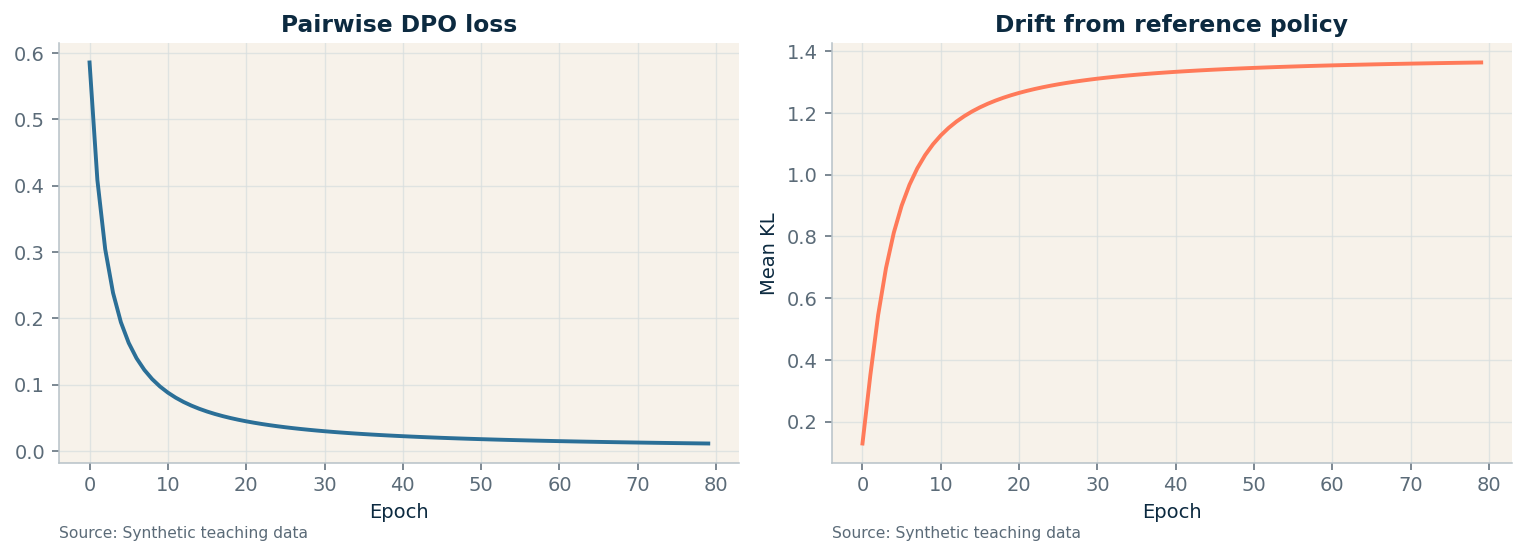

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))
axes[0].plot(history["epoch"], history["loss"], color=COLORS["blue"])
axes[0].set(title="Pairwise DPO loss", xlabel="Epoch")
axes[1].plot(history["epoch"], history["mean_kl"], color=COLORS["coral"])
axes[1].set(title="Drift from reference policy", xlabel="Epoch", ylabel="Mean KL")
for ax in axes:
    finish(ax)
plt.tight_layout()


## 2. Inspect the learned control policy


In [5]:
policy = stable_softmax(logits, axis=1)
policy_table = pd.DataFrame(policy, index=cases, columns=actions)
policy_table["selected_action"] = [actions[i] for i in policy.argmax(axis=1)]
policy_table.round(3)


,answer,clarify,refuse,escalate,selected_action
ambiguous_metric,0.000,0.997,0.002,0.002,clarify
future_document,0.000,0.001,0.997,0.001,refuse
material_trade,0.000,0.001,0.001,0.997,escalate
restricted_client,0.000,0.001,0.997,0.001,refuse
supported_summary,0.997,0.002,0.000,0.002,answer


In [6]:
test_pair_correct = np.array(
    [
        logits[case_index[row.case_type], action_index[row.chosen_action]]
        > logits[case_index[row.case_type], action_index[row.rejected_action]]
        for row in test_preferences.itertuples()
    ]
)
pair_accuracy, pair_low, pair_high = proportion_interval(
    int(test_pair_correct.sum()),
    len(test_pair_correct),
)
chosen_logp, rejected_logp, ref_chosen, ref_rejected = [], [], [], []
log_policy = np.log(np.clip(policy, 1e-12, 1))
for row in test_preferences.itertuples():
    c = case_index[row.case_type]
    chosen_logp.append(log_policy[c, action_index[row.chosen_action]])
    rejected_logp.append(log_policy[c, action_index[row.rejected_action]])
    ref_chosen.append(row.reference_margin / 2)
    ref_rejected.append(-row.reference_margin / 2)
pd.DataFrame(
    {
        "preference_accuracy": [pair_accuracy],
        "accuracy_wilson_low": [pair_low],
        "accuracy_wilson_high": [pair_high],
        "final_dpo_loss": [
            dpo_loss(
                np.array(chosen_logp),
                np.array(rejected_logp),
                np.array(ref_chosen),
                np.array(ref_rejected),
                beta=beta,
            )
        ],
        "mean_kl": [history.iloc[-1]["mean_kl"]],
    }
).round(4)


,preference_accuracy,accuracy_wilson_low,accuracy_wilson_high,final_dpo_loss,mean_kl
0,1.0,0.9287,1.0,0.011,1.3634


## 3. GRPO advantages

Advantages are normalized within each prompt group. A group with identical rewards
receives zero advantages instead of NaNs.


In [7]:
group_rewards = np.array(
    [
        [1.0, 0.3, -0.8, 0.6],
        [0.2, 0.2, 0.2, 0.2],
        [-0.4, 0.1, 1.2, 0.8],
    ]
)
advantages = grpo_advantages(group_rewards)
pd.DataFrame(
    np.c_[group_rewards, advantages],
    columns=[f"reward_{i}" for i in range(4)] + [f"advantage_{i}" for i in range(4)],
).round(3)


,reward_0,reward_1,reward_2,reward_3,advantage_0,advantage_1,advantage_2,advantage_3
0,1.0,0.3,-0.8,0.6,1.085,0.037,-1.608,0.486
1,0.2,0.2,0.2,0.2,0.000,0.000,0.000,0.000
2,-0.4,0.1,1.2,0.8,-1.335,-0.526,1.254,0.607


## 4. PPO clipping


Example batch objective: 0.17499999999999993


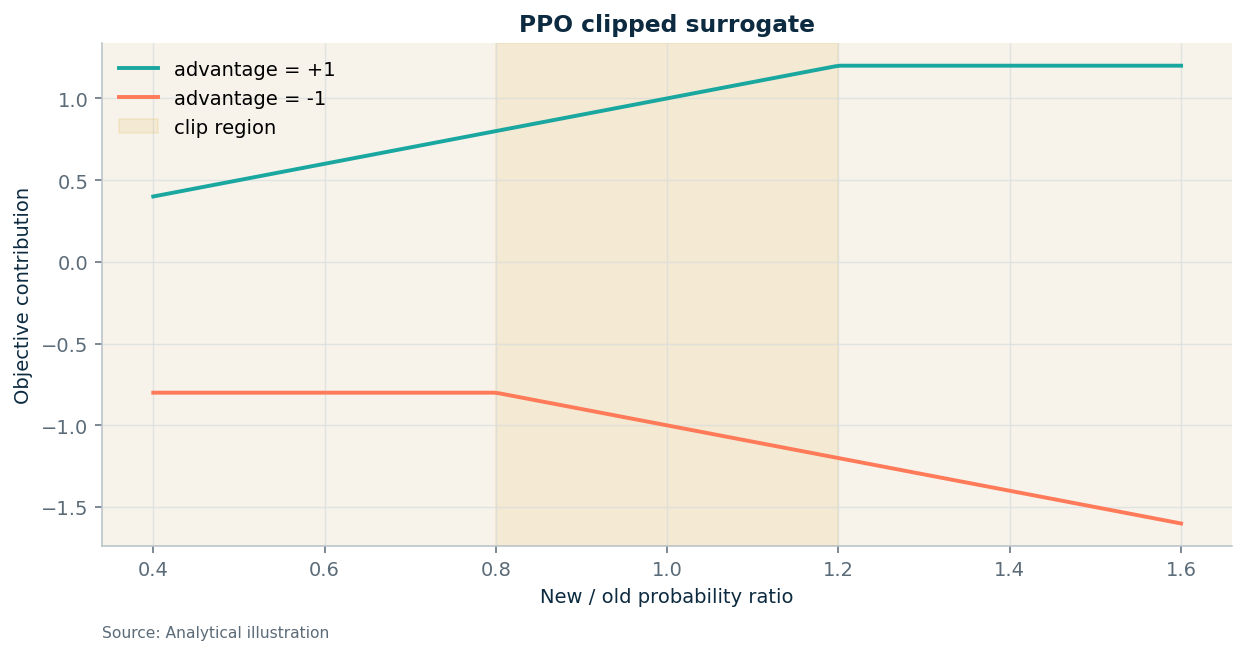

In [8]:
ratios = np.linspace(0.4, 1.6, 200)
positive = np.minimum(ratios * 1.0, np.clip(ratios, 0.8, 1.2) * 1.0)
negative = np.minimum(ratios * -1.0, np.clip(ratios, 0.8, 1.2) * -1.0)
fig, ax = plt.subplots()
ax.plot(ratios, positive, label="advantage = +1", color=COLORS["teal"])
ax.plot(ratios, negative, label="advantage = -1", color=COLORS["coral"])
ax.axvspan(0.8, 1.2, color=COLORS["gold"], alpha=0.15, label="clip region")
ax.set(title="PPO clipped surrogate", xlabel="New / old probability ratio", ylabel="Objective contribution")
ax.legend()
finish(ax, "Analytical illustration")
plt.tight_layout()
old_probabilities = np.array([0.20, 0.20])
new_probabilities = np.array([0.23, 0.15])
print(
    "Example batch objective:",
    ppo_clipped_objective(
        np.log(new_probabilities),
        np.log(old_probabilities),
        np.array([1.0, -1.0]),
    ),
)


## 5. Reward–KL frontier

`beta` changes the scale of the reference-relative margin. Under a fixed optimization
budget, preference fit and KL need not move monotonically, so both are measured rather
than asserted. A production choice needs a predeclared drift budget and safety tests.


In [9]:
frontier = []
for candidate_beta in [0.03, 0.08, 0.15, 0.30, 0.60, 1.00]:
    candidate_logits = np.zeros_like(logits)
    for _ in range(30):
        for row in train_preferences.itertuples():
            c = case_index[row.case_type]
            chosen = action_index[row.chosen_action]
            rejected = action_index[row.rejected_action]
            margin = candidate_logits[c, chosen] - candidate_logits[c, rejected]
            adjusted = candidate_beta * (margin - row.reference_margin)
            scale = candidate_beta / (1 + np.exp(adjusted))
            candidate_logits[c, chosen] += 0.08 * scale
            candidate_logits[c, rejected] -= 0.08 * scale
    candidate_policy = stable_softmax(candidate_logits, axis=1)
    accuracy = np.mean(
        [
            candidate_logits[case_index[row.case_type], action_index[row.chosen_action]]
            > candidate_logits[case_index[row.case_type], action_index[row.rejected_action]]
            for row in test_preferences.itertuples()
        ]
    )
    kl = categorical_kl(candidate_policy, np.full_like(candidate_policy, 0.25))
    frontier.append({"beta": candidate_beta, "preference_accuracy": accuracy, "mean_kl": kl})
frontier = pd.DataFrame(frontier)
frontier


,beta,preference_accuracy,mean_kl
0,0.03,1.0,0.396558
1,0.08,1.0,1.084421
2,0.15,1.0,1.275021
3,0.30,1.0,1.275752
4,0.60,1.0,1.128414
5,1.00,1.0,0.904580


## Takeaways

- DPO optimizes a chosen–rejected margin relative to a reference policy.
- GRPO removes a separate critic but still needs stable within-group normalization.
- PPO clipping limits a single update; it does not guarantee a safe policy.
- Preference accuracy is incomplete without KL, refusal, escalation, and finance-specific tests.

**Challenge:** introduce noisy or conflicting reviewer preferences and measure how policy
entropy and action stability change.
